# Solution 6D: Ledoit-Wolf Shrinkage and Minimum-Variance Portfolios
**BUSI 722: Data-Driven Finance II**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

df = pd.read_parquet("merged.parquet")

## 1. Select Technology sector stocks

In [2]:
df_tech = df[df["sector"] == "Technology"].copy()
df_sub = df_tech[df_tech["month"] >= "2023-01"].copy()
all_months = sorted(df_sub["month"].unique())
est_months = [m for m in all_months if m <= "2024-12"]
eval_months = [m for m in all_months if m >= "2025-01"]

ticker_counts = df_sub.groupby("ticker")["month"].nunique()
complete = ticker_counts[ticker_counts == len(all_months)].index.tolist()
print(f"Technology stocks with complete data (Jan 2023-Jan 2026): {len(complete)}")
print(f"Estimation: {len(est_months)} months, Evaluation: {len(eval_months)} months")

Technology stocks with complete data (Jan 2023-Jan 2026): 275
Estimation: 24 months, Evaluation: 11 months


## 2. Covariance estimation

In [3]:
df_c = df_sub[df_sub["ticker"].isin(complete)].drop_duplicates(subset=["ticker", "month"])
ret_pivot = df_c.pivot(index="month", columns="ticker", values="return")[complete].sort_index()
ret_est = ret_pivot.loc[est_months].values
ret_eval = ret_pivot.loc[eval_months].values
n = ret_est.shape[1]

S = np.cov(ret_est, rowvar=False)
lw = LedoitWolf().fit(ret_est)
S_shrunk = lw.covariance_
print(f"Shrinkage intensity (delta): {lw.shrinkage_:.4f}")

Shrinkage intensity (delta): 0.4472


## 3. Minimum-variance portfolios

In [4]:
def min_var(cov):
    n = cov.shape[0]
    result = minimize(lambda w: w @ cov @ w, np.ones(n)/n,
                      jac=lambda w: 2 * cov @ w, method="SLSQP",
                      bounds=[(0, None)] * n,
                      constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}],
                      options={"maxiter": 1000, "ftol": 1e-12})
    return result.x

w_sample = min_var(S)
w_shrunk = min_var(S_shrunk)

print(f"Sample MinVar:  {(w_sample > 0.001).sum()} stocks with weight > 0.1%, max weight = {w_sample.max():.4f}")
print(f"LW MinVar:      {(w_shrunk > 0.001).sum()} stocks with weight > 0.1%, max weight = {w_shrunk.max():.4f}")

Sample MinVar:  17 stocks with weight > 0.1%, max weight = 0.2171
LW MinVar:      60 stocks with weight > 0.1%, max weight = 0.0692


## 4. Out-of-sample evaluation

Portfolio                    Ann Vol   Ann Return     Sharpe
-----------------------------------------------------------
Sample MinVar                 0.2162       0.1659      0.767
Ledoit-Wolf MinVar            0.1511       0.1122      0.743
Equal-Weighted                0.1900       0.1046      0.550


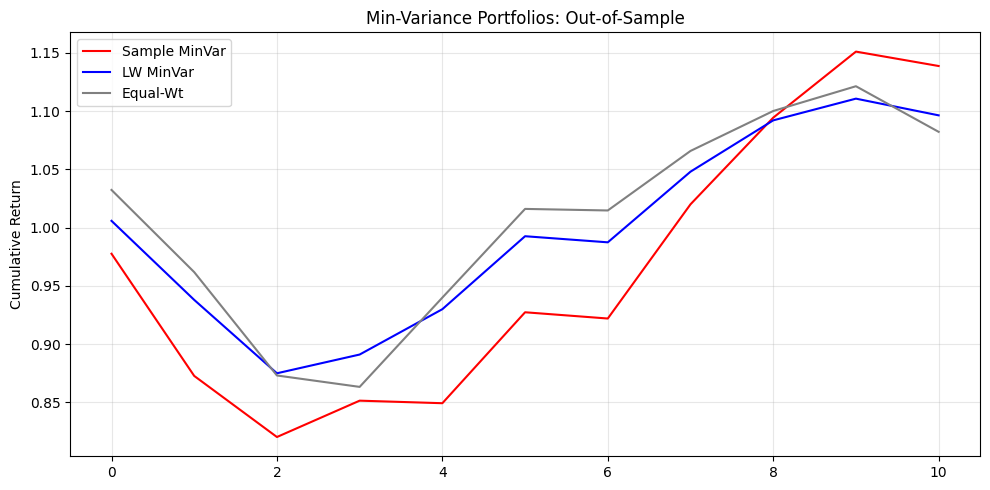

In [5]:
if len(eval_months) > 0:
    w_eq = np.ones(n) / n
    r_s, r_lw, r_eq = ret_eval @ w_sample, ret_eval @ w_shrunk, ret_eval @ w_eq

    print(f"{'Portfolio':25s} {'Ann Vol':>10s} {'Ann Return':>12s} {'Sharpe':>10s}")
    print("-" * 59)
    for name, r in [("Sample MinVar", r_s), ("Ledoit-Wolf MinVar", r_lw), ("Equal-Weighted", r_eq)]:
        print(f"{name:25s} {r.std()*np.sqrt(12):10.4f} {r.mean()*12:12.4f} "
              f"{r.mean()/r.std()*np.sqrt(12) if r.std()>0 else 0:10.3f}")

    fig, ax = plt.subplots(figsize=(10, 5))
    for name, r, c in [("Sample MinVar", r_s, "red"), ("LW MinVar", r_lw, "blue"), ("Equal-Wt", r_eq, "gray")]:
        ax.plot(range(len(r)), np.cumprod(1 + r), label=name, color=c)
    ax.set_title("Min-Variance Portfolios: Out-of-Sample")
    ax.set_ylabel("Cumulative Return")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation months available yet.")